In [170]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib qt

In [171]:
def f(x):
    return 3*x**2 - 4*x + 5

In [172]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs, ys)

In [173]:
h = 0.001
x = 0
(f(x+h) - f(x))/h

-3.9970000000000283

In [174]:
a = 2.0
b = -3.0
c = 10.0
d = a*b+c
print(d)

4.0


In [175]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b+c
c += h

d2 = a*b+c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        self.grad = 0.0 # no effect, changing of variable is not changing the loss function, AT begin very important
        self._backward = lambda:None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out
    
    def __tanh__(self):
        x = self.data
        t = (math.exp(2*x)-1)(math.exp(22)+1)
        out = Value(t, (self), 'tanh')
        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):      
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for node in reversed(topo):
            node._backward()

    
a = Value(math.pi, label='Pi')
h = Value(5.0, label = 'h')
r = Value(2.0, label = 'r')
r2 = r**2
r2.label = 'r^2'
r2Pi = a * r2
r2Pi.label = 'r^2 * Pi'
V = r2Pi * h
V.label = 'V'


In [189]:
from graphviz import Digraph

def trace(root):
    # build a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges
def draw_dot(root):
    dot = Digraph(format = 'png', graph_attr = {'rankdir':'LR'}) 
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [190]:
# V.grad = 1
# h.grad = 12.566370614359172
# r.grad = 62.83185307179586
# r2Pi.grad = 5.0

V.backward()

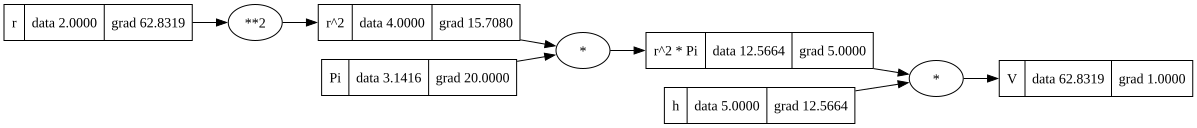

In [191]:
draw_dot(V)

In [163]:
V._backward()

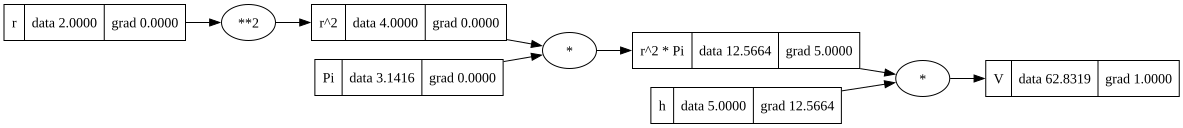

In [164]:
draw_dot(V)


In [165]:
r2Pi._backward()

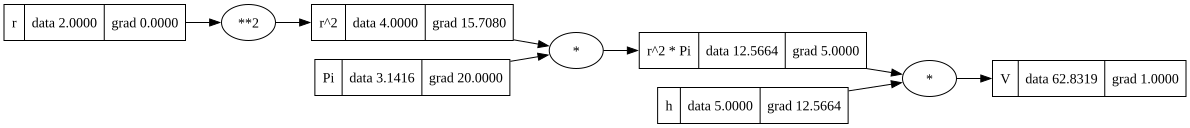

In [166]:
draw_dot(V)

In [167]:
r2._backward()

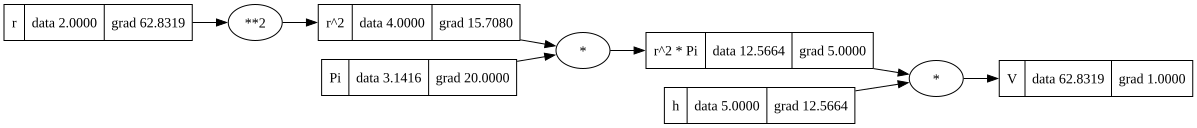

In [168]:
draw_dot(V)

In [181]:
V.grad = 1

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(V)
for node in reversed(topo):
    node._backward()

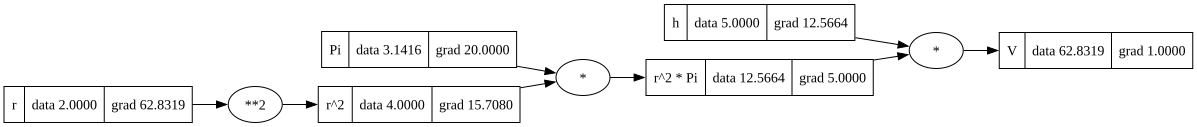

In [182]:
draw_dot(V)

In [ ]:
V = h * r2Pi
# dV/dh --> V = (r^2*pi)*h --> r^2*pi = 4*pi
# dV/d(r^2*pi) --> V = (r^2*pi)*h --> h = 5
# dV/dr2 --> r2*pi*h = pi*h 

# d(r2)/dr --> r2 = r**2 = 2*r


 

In [82]:
def lol():
    eps = 0.000000001

    a = Value(math.pi, label='Pi')
    h = Value(5.0, label = 'h')
    r = Value(2.0, label = 'r')
    r2 = r**2; r2.label='r^2'
    r2Pi = a*r2; r2Pi.label = 'r^2*Pi'
    V = r2Pi * h
    V.label = 'V'
    V1 = V.data

    a = Value(math.pi, label='Pi')
    h = Value(5.0+eps, label = 'h')
    r = Value(2.0, label = 'r')
    r2 = r**2; r2.label='r^2'
    r2Pi = a*r2; r2Pi.label = 'r^2*Pi'

    V = r2Pi * h
    V.label = 'V'
    V2 = V.data

    print((V2-V1)/eps)
lol()

12.566374607558828
